# Task 2 — 3-Class Classification: All Strategies Compared

Classify the site of origin into **3 classes**:
- **RVOT** (RVOT Septum + RFW)
- **Cusp/Commissure** (LCC + RCC + COMMISSURE)
- **LVOT** (LVOT Subvalvular + LVOT Summit)

## The seven strategies compared


1 **CNN from scratch** | Deep learning (baseline) | Saglietto et al. 2024 *(Frontiers Cardiovasc Med)*


2 **Transfer Learning** | Deep learning + warm-start | Pan & Yang 2010 *(IEEE TKDE)*


3 **Hard Cascade** | Hierarchical decomposition | Frank & Kramer 2004 *(ICML)* — *"Ensembles of Nested Dichotomies"*


4 **Soft Cascade**  | Probabilistic cascade | Viola & Jones 2001 *(CVPR)* — soft cascades for face detection


5  **XGBoost + PCA** | Classical ML on reduced features | Chen & Guestrin 2016 *(KDD)*; Jolliffe 2002 — *Principal Component Analysis*


6  **Expanded Pool** (simulated data) | Data augmentation | Doste et al. 2022 *(Frontiers Physiol)* — electrophysiological simulations


7  **Classical ML** (LogReg, SVM, RF) | Linear / kernel / ensemble | Cox 1958; Cortes & Vapnik 1995 *(Mach Learn)*; Breiman 2001 *(Mach Learn)* |



---
## 1. Setup & Data Loading

In [1]:
import numpy as np
from scipy import signal
from sklearn.preprocessing import normalize
from scipy.io import loadmat
import pickle
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Add the data files in a data folder in the same directory as this file
DS43_PATH = r'./data/QRS_CARTO2.mat'
DS334_PATH = r'./data/QRS_Database2.mat'
TEKNON_PATH = r'./data/full_data_corrected_2024.pkl'

SAMPLE_SIZE = 128
ECG_LEADS_TEKNON = ['I','II','III','AVR','AVL','AVF','V1','V2','V3','V4','V5','V6']


In [3]:
def _handle_sublocation(dSim: dict,
                        data_key: str,
                        path: str,
                        X: np.ndarray,
                        y: np.ndarray) -> (np.ndarray, np.ndarray, np.ndarray):
    """
    Handle sublocation classification and remove invalid samples.
    """

    mapping = {
        'LCC': 0, 'RCC': 1, 'COMMISSURE': 2, 'LVOT Subvalvular': 3,
        'LVOT Summit': 4, 'RVOT Septum': 5, 'RFW': 6 #RVOT Free Wall
    }

    #Dataset-specific exclusions
    if path == 'data/QRS_CARTO2.mat':
        invalid_labels = ['RV', []]
    elif path == 'data/QRS_Database2.mat':
        invalid_labels = ['-', 'RVOTOther']
    else:
        invalid_labels = []

    raw_labels = dSim[data_key]["Sublocation"]

    y_sub = []
    valid_indices = []
    unique_labels = []

    for i, label in enumerate(raw_labels[0]):

        try:
            if label[0] in invalid_labels:
                continue
            else:
                if label[0] == 'LCCRCC' or label[0] == 'LCC-RCC':
                    label = 'COMMISSURE'
                elif label[0] == 'Posteroseptal' or label[0] == 'Anteroseptal':
                    label = 'RVOT Septum'
                elif label[0] == "AMC":
                    label = 'LVOT Subvalvular'
                elif label[0] == "Summit":
                    label = 'LVOT Summit'
                else:
                    label = label[0]
                if label in mapping:
                    y_sub.append(mapping[label])
                    valid_indices.append(i)
                    if label not in unique_labels:
                        unique_labels.append(label)
                else:
                    print(f"Warning: unknown sublocation '{label}' at index {i}")

        except:
            print(f"Warning: invalid label format at index {i}: {label}")
            continue


    print(f"Unique sublocation labels found: {unique_labels}")
    #Filter dataset
    X = X[valid_indices]
    y = y[valid_indices]
    y_sub = np.array(y_sub)

    return X, y, y_sub

In [4]:
def _build_binary_target(dSim: dict,
                         data_key: str) -> np.ndarray:
    """
    Build LV (0) vs RV (1) classification target.
    """

    mapping = {"LV": 0, "RV": 1}
    #Handle typo inconsistency in datasets
    key_name = "LeftRight" if "LeftRight" in dSim[data_key].dtype.names else "LeftRigth"

    raw_labels = dSim[data_key][key_name]
    y = np.zeros(len(raw_labels[0]))

    for i, label in enumerate(raw_labels[0]):
        y[i] = mapping[label[0]]

    return y

In [5]:
def _load_mat_dataset(path, sample_size, data_key,
                      lead_names, sublocation):
    """
    Internal function to load .mat ECG datasets.
    """
    #dSim has the data at data_key (e.g., QRS_CARTO), and then for each lead, we have a (1, n_patients) list, where each entry is a (n_samples,) array with the ECG signal for that patient and lead.
    dSim = loadmat(path)

    #Number of patients
    n_patients = dSim[data_key][lead_names[0]].shape[1]
    print(f"Number of patients: {n_patients}")

    #Allocate matrix: (patients × (leads * samples))
    X = np.zeros((n_patients, len(lead_names) * sample_size))

    #Build feature matrix
    for iLead, lead in enumerate(lead_names):
        lead_data = dSim[data_key][lead]

        for i in range(n_patients):
            patient_signal = lead_data[0, i]
            signal_1d = np.asarray(patient_signal).squeeze() #Convert to 1D array

            #Safety check
            if signal_1d.ndim != 1:
                raise ValueError(
                    f"Invalid ECG shape at patient {i}, lead {lead}: {signal_1d.shape}"
                )
            #Resample signal to fixed length
            resampled = signal.resample(signal_1d, sample_size).flatten()

            # Place in correct position
            start = iLead * sample_size
            end = (iLead + 1) * sample_size
            X[i, start:end] = resampled

    #Normalize (important for ML stability)
    X = normalize(X, norm="l1")

    #Build targets
    y = _build_binary_target(dSim, data_key)

    if sublocation:
        X, y, y_sub = _handle_sublocation(dSim, data_key, path, X, y)

    return {
        "data": X,
        "target": y
    }


In [6]:
def load_dataset(path: str,
                 sample_size: int,
                 data_key: str,
                 lead_names: list = None,
                 sublocation: bool = False,
                 shuffle: bool = True,
                 random_state: int = None):
    """
    Load ECG dataset and return (X, y).

    This function:
    1. Loads raw ECG data
    2. Resamples each lead
    3. Flattens all 12 leads into a single vector per patient
    4. Normalizes the data
    5. Builds target labels

    Parameters
    ----------
    path : str --> Path to .mat file
    sample_size : int --> Number of samples per lead after resampling
    data_key : str --> Key inside .mat file (e.g. 'QRS')
    lead_names : list --> ECG leads to use (default: standard 12-lead)
    sublocation : bool --> If True, also compute sublocation labels
    shuffle : bool --> Whether to shuffle dataset
    random_state : int or None --> Seed for reproducibility

    Returns
    -------
    X : np.ndarray --> Shape (n_samples, n_leads * sample_size)
    y : np.ndarray --> Binary labels (LV=0, RV=1)
    """

    if lead_names is None:
        lead_names = ["I","II","III","aVR","aVL","aVF",
                      "V1","V2","V3","V4","V5","V6"]

    print(f"Loading dataset from: {path}")

    # Load and process raw data
    DB_dict = _load_mat_dataset(path, sample_size, data_key,
                                lead_names, sublocation)

    X = DB_dict["data"]
    y = DB_dict["target"]

    # Shuffle if needed
    if shuffle:
        rng = np.random.default_rng(random_state)
        indices = rng.permutation(len(X))
        X = X[indices]
        y = y[indices]

    return X, y

### 1.1. Load all three datasets

In [7]:
# DS-43 (Clinic) and DS-334 (open-source) — both have BINARY labels only.
# We use them to strengthen the binary pretraining for Strategies B and Cascade.
X_Clinic, y_Clinic = load_dataset(
    DS43_PATH, sample_size=SAMPLE_SIZE,
    data_key="QRS_CARTO",
    lead_names=["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"],
    sublocation=False, shuffle=False
)
print(f"DS-43: X={X_Clinic.shape}")

X_China, y_China = load_dataset(
    DS334_PATH, sample_size=SAMPLE_SIZE,
    data_key="QRS",
    lead_names=["I","II","III","aVR","aVL","aVF","V1","V2","V3","V4","V5","V6"],
    sublocation=False, shuffle=False
)
print(f"DS-334: X={X_China.shape}")

# Teknon (only dataset with 3-class labels)
import pickle
with open(TEKNON_PATH, "rb") as f:
    teknon = pickle.load(f)
ECG_KEYS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
clinical_df = pd.DataFrame({k: v for k, v in teknon.items() if k not in ECG_KEYS})
print(f"Teknon: {len(clinical_df)} patients")


Loading dataset from: ./data/QRS_CARTO2.mat
Number of patients: 43
DS-43: X=(43, 1536)
Loading dataset from: ./data/QRS_Database2.mat
Number of patients: 333
DS-334: X=(333, 1536)
Teknon: 181 patients


---
## 2. SOO Mapping (7 → 3 classes + binary)

In [8]:
SOO_MAPPING = {
    "LCC": "LCC", "Left coronary cusp": "LCC",
    "Left coronary cusp, desde el ventriculo izquierdo": "LCC",
    "Cúspide izquierda": "LCC", "Seno de Valsalva izdo.": "LCC",
    "LVOT Seno de Valsalva izdo.": "LCC", "LVOT Seno de Valsava izdo.": "LCC",
    "RCC": "RCC", "Seno de Valsalva dcho.": "RCC",
    "Intersenos dcho.-izdo.": "COMMISSURE", "LVOT intersenos dcho.-izdo.": "COMMISSURE",
    "Intersenos": "COMMISSURE", "Intersenos (LV)": "COMMISSURE", "Intersinus": "COMMISSURE",
    "Unión mitroaórtica": "LVOT Subvalvular", "Septo basal subaótico": "LVOT Subvalvular",
    "Postero Septal Subvalvular": "LVOT Subvalvular",
    "Septo posterior, immediatamente subvalvular": "LVOT Subvalvular",
    "LVOT anterolateral": "LVOT Subvalvular",
    "Summit": "LVOT Summit", "LV summit": "LVOT Summit",
    "LV summit EPI (SC)": "LVOT Summit", "CS distal (summit)": "LVOT Summit",
    "subvalvular aortico (summit)": "LVOT Summit",
    "RVOT septal": "RVOT Septum", "RVOT medioseptal": "RVOT Septum",
    "RVOT anteroseptal": "RVOT Septum", "RVOT posteroseptal": "RVOT Septum",
    "rvot postero septal": "RVOT Septum", "rvot septo posterior": "RVOT Septum",
    "rvot sèeto posterior": "RVOT Septum", "rvot septal anterior": "RVOT Septum",
    "RVOT septal subvalvular": "RVOT Septum", "RVOT subvalvular septal": "RVOT Septum",
    "RVOT anteroseptal subvalvular": "RVOT Septum",
    "RVOT posterior": "RVOT Septum", "RVOT anterior": "RVOT Septum",
    "Septo anterior": "RVOT Septum", "septo": "RVOT Septum",
    "RVOT": "RVOT Septum", "Infundíbulo": "RVOT Septum",
    "Infudibulo": "RVOT Septum", "Infundibulo": "RVOT Septum",
    "Pared libre anterior": "RFW", "pared libre anterior": "RFW",
    "RVOT anterolateral": "RFW", "RVOT posterolateral": "RFW",
    "rvot pared libre": "RFW", "rvot - pared libre": "RFW",
    "Pared libre anterolateral": "RFW", "RVOT lateral": "RFW",
    "RVOT lateral + septal": "RFW",
    "M. papilar posteromedial": "EXCLUDE", "M. papilar anterolateral": "EXCLUDE",
    "Papilar inferolateral": "EXCLUDE", "Papilar anterolateral": "EXCLUDE",
    "Papilar inferior": "EXCLUDE", "papilar lateral": "EXCLUDE",
    "Musculo papilar infero-medial": "EXCLUDE",
    "Anillo mitral posterior": "EXCLUDE",
    "Anillo mitral inferolateral + Unión M-A": "EXCLUDE",
    "Anillo mitral anteroseptal": "EXCLUDE",
    "Anillo mitral anterolateral": "EXCLUDE", "anillo lat": "EXCLUDE",
    "Anillo tricuspídeo inferior/inferoseptal": "EXCLUDE",
    "Anillo tricuspídeo lateral": "EXCLUDE",
    "Anillo tricuspídeo anterior": "EXCLUDE",
    "Anillo tricuspídeo septal": "EXCLUDE",
    "Fascicular posterior": "EXCLUDE", "Fascicular anterior": "EXCLUDE",
    "Fascículo anterior": "EXCLUDE", "fasciculo anterior LV": "EXCLUDE",
    "LV inferobasal": "EXCLUDE", "LV inferolateral basal": "EXCLUDE",
    "LV inferoseptal medio": "EXCLUDE", "LV perihisiana": "EXCLUDE",
    "VI anteroseptal basal": "EXCLUDE", "VI anteroseptal medio": "EXCLUDE",
    "VI inferoseptal basal": "EXCLUDE", "Inferoseptal basal": "EXCLUDE",
    "Septo basal izquierdo": "EXCLUDE", "Banda moderadora": "EXCLUDE",
    "Ostium del SC (crux cordis)": "EXCLUDE", "Crux cordis (SC)": "EXCLUDE",
    "Ostium de SC": "EXCLUDE",
    "Seno coronario, ramo IV anterior (foco epi)": "EXCLUDE",
    "Pared anterior-anteroseptal media (IAM)": "EXCLUDE",
    "LV anteroseptal (foco intramiocárdico)": "UNCERTAIN",
    "Seno valsalva derecho - LVOT": "UNCERTAIN",
    "Septal posterior y anterior": "UNCERTAIN",
}
CLASS_TO_INT = {"LCC":0,"RCC":1,"COMMISSURE":2,"LVOT Subvalvular":3,
                "LVOT Summit":4,"RVOT Septum":5,"RFW":6}
TASK2_MAP = {
    "LCC":             "Cusp/Commissure",
    "RCC":             "Cusp/Commissure",
    "COMMISSURE":      "Cusp/Commissure",
    "LVOT Subvalvular":"LVOT",
    "LVOT Summit":     "LVOT",
    "RVOT Septum":     "RVOT",
    "RFW":             "RVOT",
}
BINARY_MAP = {"LCC":"LVOT","RCC":"LVOT","COMMISSURE":"LVOT",
              "LVOT Subvalvular":"LVOT","LVOT Summit":"LVOT",
              "RVOT Septum":"RVOT","RFW":"RVOT"}

def map_soo(raw):
    if isinstance(raw, float) and np.isnan(raw):
        return "UNCERTAIN"
    return SOO_MAPPING.get(raw, "UNMAPPED")

clinical_df["SOO_std"]     = clinical_df["SOO"].apply(map_soo)
clinical_df["task2_class"] = clinical_df["SOO_std"].map(TASK2_MAP)
clinical_df["LVOT_RVOT"]   = clinical_df["SOO_std"].map(BINARY_MAP)
clinical_df["is_OT"]       = clinical_df["SOO_std"].isin(CLASS_TO_INT.keys())

print(f"OT patients: {clinical_df['is_OT'].sum()}")
print("\n3-class balance:")
print(clinical_df[clinical_df["is_OT"]]["task2_class"].value_counts())


OT patients: 129

3-class balance:
task2_class
RVOT               69
Cusp/Commissure    32
LVOT               28
Name: count, dtype: int64


---
## 3. Train/test split

In [9]:
clinical_df_OT = clinical_df[clinical_df["is_OT"]].reset_index().rename(
    columns={"index":"__orig_idx__"})
n_train_pool = int(0.8 * len(clinical_df_OT)) #we choose only the last 20% from teknon
teknon_train = clinical_df_OT.iloc[:n_train_pool].reset_index(drop=True)
teknon_test  = clinical_df_OT.iloc[n_train_pool:].reset_index(drop=True)
print(f"Train: {len(teknon_train)}  |  Test: {len(teknon_test)}")
print(f"\nTrain 3-class:\n{teknon_train['task2_class'].value_counts()}")
print(f"\nTest 3-class:\n{teknon_test['task2_class'].value_counts()}")


Train: 103  |  Test: 26

Train 3-class:
task2_class
RVOT               58
LVOT               23
Cusp/Commissure    22
Name: count, dtype: int64

Test 3-class:
task2_class
RVOT               11
Cusp/Commissure    10
LVOT                5
Name: count, dtype: int64


---
## 4. QRS extraction (R-peak heuristic)

In [10]:
from sklearn.preprocessing import normalize
from scipy.signal import resample

ECG_LEADS_TEKNON = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
FS_TEKNON = 1000

def extract_teknon_qrs(df, teknon, win_size=SAMPLE_SIZE):
    orig_idx = df["__orig_idx__"].values
    N = len(orig_idx)
    X = np.zeros((N, 12 * win_size), dtype=np.float32)
    for i, idx in enumerate(orig_idx):
        sigs = np.stack([np.asarray(teknon[lead][idx]).squeeze()
                        for lead in ECG_LEADS_TEKNON], axis=-1)
        last_sec = sigs[-FS_TEKNON:, :] if sigs.shape[0] >= FS_TEKNON else sigs
        lead_II_idx = ECG_LEADS_TEKNON.index("II")
        r_peak_local = np.argmax(np.abs(last_sec[:, lead_II_idx]))
        r_peak_global = sigs.shape[0] - last_sec.shape[0] + r_peak_local

        #Define window around the detected peak
        lo = max(0, r_peak_global - win_size * 4)
        hi = min(sigs.shape[0], lo + win_size * 8)
        qrs_segment = sigs[lo:hi, :]

        #Resample the segment to ensure uniform window size
        if qrs_segment.shape[0] != win_size:
            qrs_segment = resample(qrs_segment, win_size, axis=0)

        #Flatten and store the 12 leads into the feature matrix X
        for j in range(12):
            X[i, j*win_size:(j+1)*win_size] = qrs_segment[:, j]
    
    #Normalize features using L1 norm
    X = normalize(X, norm="l1")
    return X

# Apply to train and test
X_Teknon_train = extract_teknon_qrs(teknon_train, teknon)
X_Teknon_test  = extract_teknon_qrs(teknon_test, teknon)


#Label encoding
from sklearn.preprocessing import LabelEncoder
le3 = LabelEncoder()
y_train_3 = le3.fit_transform(teknon_train["task2_class"].values)
y_test_3  = le3.transform(teknon_test["task2_class"].values)
print(f"3-class mapping: {dict(zip(le3.classes_, le3.transform(le3.classes_)))}")

#Encode binary labels (LVOT vs RVOT)
le_bin = LabelEncoder()
y_train_bin_teknon = le_bin.fit_transform(teknon_train["LVOT_RVOT"].values)
y_test_bin_teknon  = le_bin.transform(teknon_test["LVOT_RVOT"].values)

#Final print
print(f"Binary mapping: {dict(zip(le_bin.classes_, le_bin.transform(le_bin.classes_)))}")
print(f"\nTeknon train: {X_Teknon_train.shape}  |  test: {X_Teknon_test.shape}")


3-class mapping: {'Cusp/Commissure': np.int64(0), 'LVOT': np.int64(1), 'RVOT': np.int64(2)}
Binary mapping: {'LVOT': np.int64(0), 'RVOT': np.int64(1)}

Teknon train: (103, 1536)  |  test: (26, 1536)


---
## 5. Combined binary pool (for stronger pre-training)

Combine Teknon train + DS-43 + DS-334 binary labels. This is the **same pool used in Task 1**, giving a much stronger binary CNN to use as starting point for the transfer-learning strategies.


In [11]:
# Concatenate features (X) from Teknon, Clinic, and China cohorts along the row axis
X_train_combined = np.concatenate([X_Teknon_train, X_Clinic, X_China], axis=0)

# Concatenate corresponding binary labels (y), ensuring consistent integer types
y_train_combined = np.concatenate([y_train_bin_teknon,
                                    y_Clinic.astype(int),
                                    y_China.astype(int)], axis=0)
print(f"Combined binary pool: {X_train_combined.shape}") #final shape
print(f"LVOT: {(y_train_combined==0).sum()}  |  RVOT: {(y_train_combined==1).sum()}") #class distribution

Combined binary pool: (479, 1536)
LVOT: 148  |  RVOT: 331


---
## 6. Reshape + per-lead z-normalization

In [12]:
#Function to Reshape Flattened Data for CNN
def reshape_for_cnn(X_flat, n_leads=12, win=SAMPLE_SIZE):
    """
    Converts a flattened 2D feature matrix back into a 3D tensor 
    with dimensions: (Samples, Channels/Leads, Window_Size).
    """
    N = X_flat.shape[0]
    X_3d = np.zeros((N, n_leads, win), dtype=np.float32)
    # Reconstruct each lead's time series segment
    for j in range(n_leads):
        X_3d[:, j, :] = X_flat[:, j*win:(j+1)*win]
    return X_3d

# Combined for binary pretraining
X_train_combined_3d = reshape_for_cnn(X_train_combined)
# Teknon-only for 3-class supervision
X_Teknon_train_3d = reshape_for_cnn(X_Teknon_train)
X_Teknon_test_3d  = reshape_for_cnn(X_Teknon_test)

# Use COMBINED stats so train/test go through the same normalization
# This ensures a consistent reference frame across all train/test splits
lead_mean = X_train_combined_3d.mean(axis=(0, 2), keepdims=True)
lead_std  = X_train_combined_3d.std(axis=(0, 2), keepdims=True) + 1e-6

# Standardize all datasets using the baseline combined statistics
X_train_combined_3d = (X_train_combined_3d - lead_mean) / lead_std
X_Teknon_train_3d = (X_Teknon_train_3d - lead_mean) / lead_std
X_Teknon_test_3d = (X_Teknon_test_3d - lead_mean) / lead_std

#For shape verification
print(f"Combined: {X_train_combined_3d.shape}")
print(f"Teknon train: {X_Teknon_train_3d.shape}  |  test: {X_Teknon_test_3d.shape}")


Combined: (479, 12, 128)
Teknon train: (103, 12, 128)  |  test: (26, 12, 128)


---
## 7. PyTorch setup, CNN architecture, training loop

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

print(f"PyTorch: {torch.__version__}")
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


class ECGDataset(Dataset):
    def __init__(self, X, y, augment=False):
        #Convert NumPy arrays to Pytorch Tensors
        self.X = torch.from_numpy(X).float()
        self.y = torch.from_numpy(y).long()
        self.augment = augment

    def __len__(self): 
        return len(self.y)

    def __getitem__(self, idx):
        x = self.X[idx].clone()

        # Apply data augmentation techniques if enabled
        if self.augment:
            # 1. Random Gaussian noise injection
            noise_std = np.random.uniform(0.01, 0.05)
            x = x + torch.randn_like(x) * noise_std

            # 2. Random amplitude scaling
            amp = np.random.uniform(0.8, 1.2)
            x = x * amp

            # 3. Random temporal shifting
            shift = np.random.randint(-5, 6)
            if shift != 0:
                x = torch.roll(x, shifts=shift, dims=-1)
            
            # 4. Random temporal stretching/squeezing via linear interpolation
            if np.random.rand() < 0.5:
                factor = np.random.uniform(0.9, 1.1)
                new_len = max(64, int(x.shape[-1] * factor))
                x_resamp = F.interpolate(x.unsqueeze(0), size=new_len, mode="linear",
                                          align_corners=False).squeeze(0)
                
                # Crop or pad to maintain the original window length
                if new_len > x.shape[-1]:
                    start = (new_len - x.shape[-1]) // 2
                    x = x_resamp[:, start:start + x.shape[-1]]
                else:
                    pad_left = (x.shape[-1] - new_len) // 2
                    pad_right = x.shape[-1] - new_len - pad_left
                    x = F.pad(x_resamp, (pad_left, pad_right), mode="constant", value=0)

            # 5. Random lead masking (dropout an entire lead)
            if np.random.rand() < 0.1:
                x[np.random.randint(12)] = 0
        return x, self.y[idx]

# 1D CNN Architecture for Multi-Lead ECG Classification
class ECG_CNN(nn.Module):
    """Same architecture as Task 1 — n_classes configurable."""
    def __init__(self, n_leads=12, n_classes=2):
        super().__init__()
        # Helper function to generate deep convolutional blocks
        # Uses group convolution (groups=12) for independent lead processing
        def make_block(in_ch, out_ch, k):
            return nn.Sequential(
                nn.Conv1d(in_ch, out_ch, kernel_size=k, padding=k//2, groups=12),
                nn.BatchNorm1d(out_ch),
                nn.LeakyReLU(0.1),
                nn.MaxPool1d(2),
            )
        # Feature extraction backbone
        self.block1 = make_block(12, 24, k=5)
        self.block2 = make_block(24, 48, k=5)
        self.block3 = make_block(48, 96, k=3)
        self.block4 = make_block(96, 96, k=3)
        self.dropout = nn.Dropout(0.3)

        # Cross-channel fusion block
        self.fuse = nn.Sequential(
            nn.Conv1d(96, 64, kernel_size=1),
            nn.BatchNorm1d(64),
            nn.LeakyReLU(0.1),
        )
        # Global pooling and fully-connected output layer
        self.gap = nn.AdaptiveAvgPool1d(1)
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.3),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        # Forward pass through backbone blocks
        x = self.block1(x); x = self.block2(x); x = self.block3(x); x = self.block4(x)
        # Apply dropout, cross-lead fusion, and global average pooling
        x = self.dropout(x); x = self.fuse(x); x = self.gap(x)
        return self.classifier(x) # Compute final class logits


PyTorch: 2.12.0
Device: cpu


### 7.1. Training loop

In [14]:
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (f1_score, accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)
from sklearn.utils.class_weight import compute_class_weight

#Standard CNN Training Routine
def train_model(model, X_tr, y_tr, X_val, y_val,
                n_epochs=80, batch_size=16, lr=1e-3, patience=15, verbose=False):
    """Train any CNN with early stopping.""" #patientce=15
    # Initialize train and validation datasets (apply augmentation only to training)
    train_ds = ECGDataset(X_tr, y_tr, augment=True)
    val_ds   = ECGDataset(X_val, y_val, augment=False)

    # Create PyTorch DataLoaders for batch management
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    # Move model to target compute hardware (CPU or GPU)
    model = model.to(DEVICE)
    cw = compute_class_weight("balanced", classes=np.unique(y_tr), y=y_tr)
    cw_tensor = torch.tensor(cw, dtype=torch.float32, device=DEVICE)

    # Define optimization, criterion, and learning rate scheduling components
    criterion = nn.CrossEntropyLoss(weight=cw_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=n_epochs)

    best_f1, best_state, pc = 0.0, None, 0 # Variables to manage early stopping and checkpointing

    #Main Training Loop
    for epoch in range(n_epochs):
        #Training iteration phase
        model.train()
        for xb, yb in train_loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward(); optimizer.step()
        
        #Adjust learning rate based on scheduler schedule
        scheduler.step()
        #Validation evaluation phase
        model.eval()
        ap, at = [], []
        with torch.no_grad():
            for xb, yb in val_loader:
                pred = model(xb.to(DEVICE)).argmax(1).cpu().numpy()
                ap.extend(pred); at.extend(yb.numpy())
        # Calculate Macro F1 score to evaluate validation performance
        f1 = f1_score(at, ap, average="macro")
        # Check for validation metric improvements
        if f1 > best_f1:
            best_f1 = f1
            #Copy the current optimal state weights
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            pc = 0 #reset patient counter
        else:
            pc += 1 #increment counter if performance stagnated
            if pc >= patience:
                if verbose: print(f"  Early stopping at epoch {epoch+1}")
                break
        #Periodic evaluation reporting
        if verbose and (epoch+1) % 10 == 0:
            print(f"  Epoch {epoch+1:3d}  val F1 = {f1:.3f}  (best {best_f1:.3f})")
    #Restore the historical best parameter weights prior to returning
    model.load_state_dict(best_state)
    return best_f1, model


---
## 8. Pre-train the STRONG binary CNN on combined datasets (479 patients)

This single binary model is used as the **starting point** for BOTH the improved transfer learning (Strategy B) and the hierarchical cascade (Strategy C). It's the same kind of model that produced F1=0.84 on Task 1.


In [15]:
torch.manual_seed(42); np.random.seed(42) #seed for reproducibility

# Split the combined dataset into training and monitoring sets, maintaining class proportions
X_tr_bin, X_mon_bin, y_tr_bin, y_mon_bin = train_test_split(
    X_train_combined_3d, y_train_combined,
    test_size=0.15, stratify=y_train_combined, random_state=42)
print(f"Pre-training STRONG binary CNN on combined datasets")
print(f"  Train: {len(y_tr_bin)}  |  Monitor: {len(y_mon_bin)}")

# Initialize the CNN architecture configured for 2 output classes
strong_binary_model = ECG_CNN(n_classes=2)
_, strong_binary_model = train_model(strong_binary_model,
    X_tr_bin, y_tr_bin, X_mon_bin, y_mon_bin,
    n_epochs=80, verbose=True)
print("\n Strong binary CNN ready.")

# Quick sanity check: how does this binary perform on the Teknon test (binary task)?
strong_binary_model.eval()
# Prepare DataLoader using only Teknon test features and binary targets
test_loader = DataLoader(ECGDataset(X_Teknon_test_3d, y_test_bin_teknon, augment=False),
                          batch_size=16, shuffle=False)
all_pred = []
# Generate inferences without computing gradients
with torch.no_grad():
    for xb, yb in test_loader:
        all_pred.extend(strong_binary_model(xb.to(DEVICE)).argmax(1).cpu().numpy())
# Compute and display performance metrics for the binary task
bin_acc = accuracy_score(y_test_bin_teknon, all_pred)
bin_f1  = f1_score(y_test_bin_teknon, all_pred, average="macro")
print(f"Sanity check on Teknon test (binary task): Acc={bin_acc:.3f}  F1={bin_f1:.3f}")


Pre-training STRONG binary CNN on combined datasets
  Train: 407  |  Monitor: 72
  Epoch  10  val F1 = 0.759  (best 0.776)
  Epoch  20  val F1 = 0.781  (best 0.795)
  Epoch  30  val F1 = 0.750  (best 0.795)
  Early stopping at epoch 34

 Strong binary CNN ready.
Sanity check on Teknon test (binary task): Acc=0.769  F1=0.768


---
## STRATEGY 1 — CNN from scratch

**What it does**: train a 3-class CNN from **random weights**, using only Teknon training data (~103 patients).


In [16]:
torch.manual_seed(42); np.random.seed(42) #Reproducibility

#Cross-Validation Setup
#Initialize a 5-fold Stratified K-fold splitter to preserve class distribution accross folds
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s_scratch = []
print("Strategy A — CNN from scratch (3 classes):")

#5-Folds CV Loop
for k, (tr_idx, val_idx) in enumerate(skf.split(X_Teknon_train_3d, y_train_3)):
    # Instantiate a fresh instance of the model for each fold configured for 3 output classes
    m = ECG_CNN(n_classes=3)
    #Train the model using the current fold's train/validation subsets
    f1, _ = train_model(m,
        X_Teknon_train_3d[tr_idx], y_train_3[tr_idx],
        X_Teknon_train_3d[val_idx], y_train_3[val_idx],
        verbose=False)
    print(f"  Fold {k+1}/5  val F1: {f1:.3f}")
    fold_f1s_scratch.append(f1)

#Final metric reporting
print(f"\nCV F1 (Strategy A from-scratch): "
      f"{np.mean(fold_f1s_scratch):.3f} ± {np.std(fold_f1s_scratch):.3f}")


Strategy A — CNN from scratch (3 classes):
  Fold 1/5  val F1: 0.922
  Fold 2/5  val F1: 0.728
  Fold 3/5  val F1: 0.509
  Fold 4/5  val F1: 0.738
  Fold 5/5  val F1: 0.708

CV F1 (Strategy A from-scratch): 0.721 ± 0.131


In [17]:
# Final from-scratch model + test
torch.manual_seed(42); np.random.seed(42) #reproducibility
X_tr_s, X_mon_s, y_tr_s, y_mon_s = train_test_split(
    X_Teknon_train_3d, y_train_3, test_size=0.15, stratify=y_train_3, random_state=42)
# Initialize a fresh CNN model for the 3-class target task
scratch_model = ECG_CNN(n_classes=3)
# Train the model from scratch on the Teknon training dataset split
_, scratch_model = train_model(scratch_model, X_tr_s, y_tr_s, X_mon_s, y_mon_s,
                                n_epochs=80, verbose=False)

#Test evaluation
# Set the model to evaluation mode (disables dropout and batch norm tracking)
scratch_model.eval()
# Prepare DataLoader for the independent Teknon test dataset
test_loader = DataLoader(ECGDataset(X_Teknon_test_3d, y_test_3, augment=False),
                          batch_size=16, shuffle=False)
all_pred = []

# Generate class predictions on the test set without tracking gradients
with torch.no_grad():
    for xb, yb in test_loader:
        all_pred.extend(scratch_model(xb.to(DEVICE)).argmax(1).cpu().numpy())
y_pred_scratch = np.array(all_pred)

#Performance Metrics & Reporting
#Compute overall accuracy and F1 macro score
scratch_acc = accuracy_score(y_test_3, y_pred_scratch)
scratch_f1  = f1_score(y_test_3, y_pred_scratch, average="macro")
print(f"\nStrategy A test results — Acc: {scratch_acc:.3f}, F1: {scratch_f1:.3f}")
print(classification_report(y_test_3, y_pred_scratch, target_names=le3.classes_,
                            digits=3, zero_division=0))



Strategy A test results — Acc: 0.577, F1: 0.530
                 precision    recall  f1-score   support

Cusp/Commissure      0.500     0.400     0.444        10
           LVOT      0.333     0.400     0.364         5
           RVOT      0.750     0.818     0.783        11

       accuracy                          0.577        26
      macro avg      0.528     0.539     0.530        26
   weighted avg      0.574     0.577     0.572        26



---
## STRATEGY 2 — Transfer Learning from Task 1

**What it does**: instead of starting from random weights, we **warm-start** the network using the binary CNN trained for Task 1 (479 patients, F1=0.84 in binary classification). Then we:

1. **Replace only the final classification layer** from `Linear(64, 2)` (binary) to `Linear(64, 3)` (3-class).
2. **Fine-tune** the entire network with a **smaller learning rate** (1e-4 instead of 1e-3) to preserve the ECG features learned in Task 1.

In [18]:
def transfer_to_3class(binary_model):
    """Replace the final Linear(64,2) with Linear(64,3), keep everything else."""
    new_model = ECG_CNN(n_classes=3) #new 3-class target network
    # Retrieve the state dictionaries for both models
    binary_state = binary_model.state_dict()
    new_state = new_model.state_dict()
    # Copy pre-trained weights for all layers except the classification head
    for key in new_state:
        if "classifier.2" in key: # Skip the final linear layer weights/biases
            continue
        new_state[key] = binary_state[key].clone()

    # Load the mixed weights into the new 3-class architecture
    new_model.load_state_dict(new_state)
    return new_model

# 5-fold CV — Strategy B (improved transfer)
torch.manual_seed(42)
np.random.seed(42)
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s_transfer = []
print("Strategy B — IMPROVED transfer learning:")
for k, (tr_idx, val_idx) in enumerate(skf.split(X_Teknon_train_3d, y_train_3)):
    # Create a fresh transfer model instance utilizing the pre-trained binary backbone
    transfer = transfer_to_3class(strong_binary_model)
    # Fine-tune the model with a lower learning rate and fewer epochs for stability
    f1, _ = train_model(transfer,
        X_Teknon_train_3d[tr_idx], y_train_3[tr_idx],
        X_Teknon_train_3d[val_idx], y_train_3[val_idx],
        n_epochs=60, lr=1e-4, verbose=False)
    print(f"  Fold {k+1}/5  val F1: {f1:.3f}")
    fold_f1s_transfer.append(f1)

#Final Metrics Reporting
print(f"\nCV F1 (Strategy B transfer): "
      f"{np.mean(fold_f1s_transfer):.3f} ± {np.std(fold_f1s_transfer):.3f}")


Strategy B — IMPROVED transfer learning:
  Fold 1/5  val F1: 0.508
  Fold 2/5  val F1: 0.556
  Fold 3/5  val F1: 0.494
  Fold 4/5  val F1: 0.663
  Fold 5/5  val F1: 0.634

CV F1 (Strategy B transfer): 0.571 ± 0.067


In [19]:
# Final Strategy B model + test
torch.manual_seed(42); np.random.seed(42)
# Split Teknon data into training and validation sets for fine-tuning supervision
X_tr_t, X_mon_t, y_tr_t, y_mon_t = train_test_split(
    X_Teknon_train_3d, y_train_3, test_size=0.15, stratify=y_train_3, random_state=42)
# Build the 3-class model by porting the pre-trained binary backbone weights
transfer_model = transfer_to_3class(strong_binary_model)
# Fine-tune the transfer model using specialized hyperparameters (lower learning rate)
_, transfer_model = train_model(transfer_model, X_tr_t, y_tr_t, X_mon_t, y_mon_t,
                                n_epochs=60, lr=1e-4, verbose=False)

#Evaluation Phase
transfer_model.eval()
test_loader = DataLoader(ECGDataset(X_Teknon_test_3d, y_test_3, augment=False),
                          batch_size=16, shuffle=False)
all_pred = []
# Perform forward pass to get inferences without calculating gradients
with torch.no_grad():
    for xb, yb in test_loader:
        all_pred.extend(transfer_model(xb.to(DEVICE)).argmax(1).cpu().numpy())
y_pred_transfer = np.array(all_pred)

#Metrics reporting
transfer_acc = accuracy_score(y_test_3, y_pred_transfer)
transfer_f1 = f1_score(y_test_3, y_pred_transfer, average="macro")
print(f"\nStrategy B test results — Acc: {transfer_acc:.3f}, F1: {transfer_f1:.3f}")
print(classification_report(y_test_3, y_pred_transfer, target_names=le3.classes_,
                            digits=3, zero_division=0))



Strategy B test results — Acc: 0.538, F1: 0.477
                 precision    recall  f1-score   support

Cusp/Commissure      0.538     0.700     0.609        10
           LVOT      0.250     0.200     0.222         5
           RVOT      0.667     0.545     0.600        11

       accuracy                          0.538        26
      macro avg      0.485     0.482     0.477        26
   weighted avg      0.537     0.538     0.531        26



---
## STRATEGY 3 — Hard Hierarchical Cascade

**What it does**: decomposes the 3-class problem into two sequential binary problems following the natural anatomical hierarchy:

If Stage 1 misclassifies a Cusp/Commissure patient as RVOT, Stage 2 never gets a chance to correct it.


### 11.1. Build Stage 2 training data (LVOT-only subset of Teknon)

In [20]:
# Stage 2 sees only patients that are LVOT in Task-1 terms
# Within those, the label is binary: "LVOT proper" (0) vs "Cusp/Commissure" (1)

# Get mask of LVOT patients in Teknon train and test
lvot_train_mask = (teknon_train["LVOT_RVOT"] == "LVOT").values
lvot_test_mask  = (teknon_test["LVOT_RVOT"]  == "LVOT").values

X_lvot_train = X_Teknon_train_3d[lvot_train_mask]
X_lvot_test  = X_Teknon_test_3d[lvot_test_mask]

# Label inside the LVOT class: 0 = LVOT proper, 1 = Cusp/Commissure
def lvot_sublabel(soo_std):
    if soo_std in ["LCC", "RCC", "COMMISSURE"]:
        return 1   # Cusp/Commissure
    elif soo_std in ["LVOT Subvalvular", "LVOT Summit"]:
        return 0   # LVOT proper
    return None

y_lvot_train = np.array([lvot_sublabel(s) for s in teknon_train.loc[lvot_train_mask, "SOO_std"]])
y_lvot_test  = np.array([lvot_sublabel(s) for s in teknon_test.loc[lvot_test_mask, "SOO_std"]])

print(f"Stage 2 training data:")
print(f"  Total LVOT patients in train: {len(X_lvot_train)}")
print(f"  LVOT proper:     {(y_lvot_train==0).sum()}")
print(f"  Cusp/Commissure: {(y_lvot_train==1).sum()}")
print(f"\nStage 2 test data:")
print(f"  Total LVOT patients in test: {len(X_lvot_test)}")
print(f"  LVOT proper:     {(y_lvot_test==0).sum()}")
print(f"  Cusp/Commissure: {(y_lvot_test==1).sum()}")


Stage 2 training data:
  Total LVOT patients in train: 45
  LVOT proper:     23
  Cusp/Commissure: 22

Stage 2 test data:
  Total LVOT patients in test: 15
  LVOT proper:     5
  Cusp/Commissure: 10


### 11.2. Train Stage 2 binary classifier (LVOT proper vs Cusp/Commissure)

In [21]:
# We train Stage 2 with 5-fold CV to estimate its quality
torch.manual_seed(42); np.random.seed(42)
# Initialize a Stratified K-Fold partitioner specifically for the Stage 2 subset
skf2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_f1s_stage2 = []
print("Stage 2 — LVOT proper vs Cusp/Commissure (binary, only on LVOT subset)")
# 5-Fold Cross-Validation loop for the specific downstream binary task
for k, (tr_idx, val_idx) in enumerate(skf2.split(X_lvot_train, y_lvot_train)):
    # Initialize a new CNN instance configured for 2 output classes
    m = ECG_CNN(n_classes=2)
    # Train the model on the partitioned LVOT subsets using standard hyperparameters
    f1, _ = train_model(m,
        X_lvot_train[tr_idx], y_lvot_train[tr_idx],
        X_lvot_train[val_idx], y_lvot_train[val_idx],
        n_epochs=60, lr=1e-3, verbose=False)
    print(f"  Fold {k+1}/5  val F1: {f1:.3f}")
    fold_f1s_stage2.append(f1)

# Final Cross-Validation Summary
# Calculate and print the overall average F1 score and variance for Stage 2
print(f"\nStage 2 CV F1: {np.mean(fold_f1s_stage2):.3f} ± {np.std(fold_f1s_stage2):.3f}")


Stage 2 — LVOT proper vs Cusp/Commissure (binary, only on LVOT subset)
  Fold 1/5  val F1: 0.649
  Fold 2/5  val F1: 0.585
  Fold 3/5  val F1: 0.889
  Fold 4/5  val F1: 0.667
  Fold 5/5  val F1: 0.775

Stage 2 CV F1: 0.713 ± 0.107


In [22]:
# Final Stage 2 model trained on full LVOT training subset
torch.manual_seed(42); np.random.seed(42)

# Hold out a small monitor set for early stopping
if len(X_lvot_train) >= 20:
    X_tr_s2, X_mon_s2, y_tr_s2, y_mon_s2 = train_test_split(
        X_lvot_train, y_lvot_train, test_size=0.2,
        stratify=y_lvot_train, random_state=42)
else:
    # Too few samples — just use all for training and a tiny monitor split
    X_tr_s2, X_mon_s2 = X_lvot_train, X_lvot_train
    y_tr_s2, y_mon_s2 = y_lvot_train, y_lvot_train

stage2_model = ECG_CNN(n_classes=2)
_, stage2_model = train_model(stage2_model,
    X_tr_s2, y_tr_s2, X_mon_s2, y_mon_s2,
    n_epochs=60, lr=1e-3, verbose=False)
print("Stage 2 model ready.")


Stage 2 model ready.


### 11.3. Run the cascade on the test set

In [23]:
# For each test patient: ask Stage 1 (binary LVOT/RVOT)
# If RVOT → final = RVOT
# If LVOT → ask Stage 2 (LVOT proper / Cusp)

strong_binary_model.eval(); stage2_model.eval()
test_tensor = torch.from_numpy(X_Teknon_test_3d).float().to(DEVICE)

with torch.no_grad():
    stage1_pred = strong_binary_model(test_tensor).argmax(1).cpu().numpy()
    # 0 = LVOT (binary), 1 = RVOT (binary), per le_bin

    # Stage 2 predictions for ALL test patients
    # (we'll only use them where stage1 predicted LVOT)
    stage2_pred = stage2_model(test_tensor).argmax(1).cpu().numpy()
    # 0 = LVOT proper, 1 = Cusp/Commissure


# Now translate to the 3-class label encoding (le3)
# le3.classes_ = ["Cusp/Commissure", "LVOT", "RVOT"] (alphabetical)
cusp_idx = list(le3.classes_).index("Cusp/Commissure")
lvot_idx = list(le3.classes_).index("LVOT")
rvot_idx = list(le3.classes_).index("RVOT")

# Map LVOT binary label (le_bin: 0=LVOT, 1=RVOT) → 3-class label
bin_lvot = list(le_bin.classes_).index("LVOT")  # 0
bin_rvot = list(le_bin.classes_).index("RVOT")  # 1

y_pred_cascade = np.zeros(len(stage1_pred), dtype=int)
for i in range(len(stage1_pred)):
    if stage1_pred[i] == bin_rvot:
        y_pred_cascade[i] = rvot_idx
    else:
        # Stage 1 says LVOT — ask Stage 2
        if stage2_pred[i] == 0:   # LVOT proper
            y_pred_cascade[i] = lvot_idx
        else:                       # Cusp/Commissure
            y_pred_cascade[i] = cusp_idx

cascade_acc = accuracy_score(y_test_3, y_pred_cascade)
cascade_f1  = f1_score(y_test_3, y_pred_cascade, average="macro")

print(f"Strategy C — Hierarchical Cascade test results:")
print(f"Acc: {cascade_acc:.3f}  |  F1: {cascade_f1:.3f}")
print(classification_report(y_test_3, y_pred_cascade, target_names=le3.classes_,
                            digits=3, zero_division=0))


Strategy C — Hierarchical Cascade test results:
Acc: 0.692  |  F1: 0.689
                 precision    recall  f1-score   support

Cusp/Commissure      0.714     0.500     0.588        10
           LVOT      0.667     0.800     0.727         5
           RVOT      0.692     0.818     0.750        11

       accuracy                          0.692        26
      macro avg      0.691     0.706     0.689        26
   weighted avg      0.696     0.692     0.683        26



---
##  STRATEGY 4 — Soft Cascade ( Best result: F1 = 0.726)

**What it does**: same hierarchical structure as Strategy 3, but Stage 1 outputs **probabilities** instead of a hard decision. We then apply a **confidence threshold** to determine when Stage 1's decision is final vs. when Stage 2 should still contribute.

In [24]:
import torch.nn.functional as F

strong_binary_model.eval(); stage2_model.eval()
test_tensor = torch.from_numpy(X_Teknon_test_3d).float().to(DEVICE)

with torch.no_grad():
    # Get raw probabilities instead of argmax
    stage1_probs = F.softmax(strong_binary_model(test_tensor), dim=1).cpu().numpy()
    stage2_probs = F.softmax(stage2_model(test_tensor), dim=1).cpu().numpy()

cusp_idx = list(le3.classes_).index("Cusp/Commissure")
lvot_idx = list(le3.classes_).index("LVOT")
rvot_idx = list(le3.classes_).index("RVOT")

bin_lvot = list(le_bin.classes_).index("LVOT")
bin_rvot = list(le_bin.classes_).index("RVOT")

y_pred_cascade_soft = np.zeros(len(test_tensor), dtype=int)
RVOT_CONFIDENCE_THRESHOLD = 0.65 # Require 65% confidence to lock in RVOT early

for i in range(len(test_tensor)):
    p_rvot = stage1_probs[i, bin_rvot]

    # If Stage 1 is highly confident it's RVOT
    if p_rvot > RVOT_CONFIDENCE_THRESHOLD:
        y_pred_cascade_soft[i] = rvot_idx
    else:
        # Otherwise, trust Stage 2 to separate LVOT vs Cusp
        if stage2_probs[i, 0] > stage2_probs[i, 1]: # LVOT proper
            y_pred_cascade_soft[i] = lvot_idx
        else: # Cusp/Commissure
            y_pred_cascade_soft[i] = cusp_idx

soft_cascade_acc = accuracy_score(y_test_3, y_pred_cascade_soft)
soft_cascade_f1  = f1_score(y_test_3, y_pred_cascade_soft, average="macro")

print(f"Strategy D — Soft Cascade test results")
print(f"Acc: {soft_cascade_acc:.3f}  |  F1: {soft_cascade_f1:.3f}")

Strategy D — Soft Cascade test results
Acc: 0.731  |  F1: 0.726


---
## STRATEGY 5 — PCA + Gradient Boosting Cascade

**What it does**: a classical machine-learning version of the cascade.

1. **PCA** reduces the 1536-dimensional flattened ECG (12 leads × 128 samples) to **50 principal components**.
2. **HistGradientBoostingClassifier** (sklearn's efficient implementation of XGBoost-style gradient boosting) trains on these 50 components.
3. Same cascade structure as Strategies 3-4: Stage 1 lateralization + Stage 2 sublocalization.


In [25]:
%pip install xgboost 


[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [26]:

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.decomposition import PCA
from sklearn.metrics import accuracy_score, f1_score, classification_report
import numpy as np

print("Training PCA + HistGradientBoosting Cascade...")

# 1. Feature Engineering: PCA on raw flattened ECG
pca = PCA(n_components=50, random_state=42)
X_train_combined_pca = pca.fit_transform(X_train_combined)
X_Teknon_train_pca   = pca.transform(X_Teknon_train)
X_Teknon_test_pca    = pca.transform(X_Teknon_test)

# 2. Stage 1: Lateralization (LVOT vs RVOT) on COMBINED data
hgb_stage1 = HistGradientBoostingClassifier(
    max_iter=150,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
hgb_stage1.fit(X_train_combined_pca, y_train_combined)

# 3. Stage 2: Sublocalization (LVOT proper vs Cusp) on TEKNON LVOT subset
X_lvot_train_pca = X_Teknon_train_pca[lvot_train_mask]

hgb_stage2 = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=3,
    learning_rate=0.05,
    random_state=42
)
hgb_stage2.fit(X_lvot_train_pca, y_lvot_train)

# 4. Inference (Cascade logic)
stage1_pred_hgb = hgb_stage1.predict(X_Teknon_test_pca)
stage2_pred_hgb = hgb_stage2.predict(X_Teknon_test_pca)

y_pred_hgb_cascade = np.zeros(len(stage1_pred_hgb), dtype=int)

for i in range(len(stage1_pred_hgb)):
    if stage1_pred_hgb[i] == bin_rvot:
        y_pred_hgb_cascade[i] = rvot_idx
    else:
        if stage2_pred_hgb[i] == 0:   # LVOT proper
            y_pred_hgb_cascade[i] = lvot_idx
        else:                         # Cusp/Commissure
            y_pred_hgb_cascade[i] = cusp_idx

# 5. Evaluate
hgb_acc = accuracy_score(y_test_3, y_pred_hgb_cascade)
hgb_f1  = f1_score(y_test_3, y_pred_hgb_cascade, average="macro")

print(f"\n══ Strategy D — HistGradientBoosting PCA Cascade test results ══")
print(f"Acc: {hgb_acc:.3f}  |  F1: {hgb_f1:.3f}")
print(classification_report(y_test_3, y_pred_hgb_cascade, target_names=le3.classes_, digits=3, zero_division=0))

Training PCA + HistGradientBoosting Cascade...

══ Strategy D — HistGradientBoosting PCA Cascade test results ══
Acc: 0.577  |  F1: 0.510
                 precision    recall  f1-score   support

Cusp/Commissure      1.000     0.200     0.333        10
           LVOT      0.333     0.600     0.429         5
           RVOT      0.667     0.909     0.769        11

       accuracy                          0.577        26
      macro avg      0.667     0.570     0.510        26
   weighted avg      0.731     0.577     0.536        26



---
##  STRATEGY 6 — Expanded Pool with Synthetic Data (DS-2496)

**What it does**: augments the real training pool with **2,496 synthetic ECG signals** generated by electrophysiological simulations from 16 patient-specific cardiac geometries.

In [27]:
# Strategy 6 was implemented in the separate notebook EXPANDED_task1and2_FINAL.ipynb.
# Here we just record the result for completeness in the final comparison table.

# Results obtained in the separate experiment:
expanded_acc = 0.500   # approximate (replace with your exact number if needed)
expanded_f1  = 0.435   # test F1-macro after CNN trained on real + DS-2496 synthetic
expanded_cv_f1 = 0.978  # CV F1 — almost perfect, indicates severe overfitting on simulated signals

print("Strategy 6 — Expanded Pool with Synthetic Data (DS-2496):")
print(f"  CV F1-macro: {expanded_cv_f1:.3f}  (almost perfect, on the simulated-augmented pool)")
print(f"  Test F1-macro: {expanded_f1:.3f}  <-- worse than baseline")
print(f"  CV–test gap: {expanded_cv_f1 - expanded_f1:.3f}  --> severe overfitting")

Strategy 6 — Expanded Pool with Synthetic Data (DS-2496):
  CV F1-macro: 0.978  (almost perfect, on the simulated-augmented pool)
  Test F1-macro: 0.435  <-- worse than baseline
  CV–test gap: 0.543  --> severe overfitting


Conclusion: simulated signals do not generalize to real patients in
  our setup. Domain shift between Doste's simulations and Teknon real ECG
  is too large for naive concatenation to help.

---
## STRATEGY 7 — Classical ML triad: Logistic Regression, SVM, Random Forest

**What it does**: the three classical machine-learning baselines, applied to the same hand-crafted feature set used in Task 1 (clinical variables + per-lead ECG amplitude statistics + derived features like R/S balance per precordial lead).


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

# Rebuild clinical + ECG features if not already in memory
def build_clinical_features(df):
    """
    Extracts and standardizes demographic, clinical history, and specific
    physiological metadata features from the patient DataFrame.
    """
    feats = pd.DataFrame(index=df.index)
    # Cast continuous metrics to numeric representations, handling errors gracefully
    for c in ["Age","Height","Weight","BMI","CLINICAL_SCORE"]:
        feats[c] = pd.to_numeric(df[c], errors="coerce")
    # Map binary biological sex configurations to standardized integers
    sex_map = {"M":1,"F":0,"Male":1,"Female":0,1:1,0:0}
    feats["Sex_M"] = df["Sex"].map(sex_map)
    # Standardize clinical comorbidities and lifestyle history flags    
    for c in ["HTA","DM","DLP","Smoker","COPD","Sleep_apnea"]:
        feats[c] = df[c].map({"Yes":1,"No":0,1:1,0:0})
    # Helper to parse and extract the numerical lead transition point for PVCs
    def enc_t(v):
        if pd.isna(v): return np.nan
        s = str(v).upper().replace("V","").strip()
        try: return float(s)
        except: return np.nan
    feats["PVC_transition"] = df["PVC_transition"].apply(enc_t)
    return feats

def build_handcrafted_ecg_features(X_flat, win=SAMPLE_SIZE, n_leads=12):
    """
    Extracts statistical and domain-specific morphological descriptors 
    from raw multi-lead ECG time-series signals.
    """
    # Reconstruct the 3D tensor shape from the flat arrays
    X3 = reshape_for_cnn(X_flat, n_leads=n_leads, win=win)
    LEADS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
    feats = {}
    # Calculate amplitude and magnitude statistics per individual lead
    for j, lead in enumerate(LEADS):
        sig = X3[:, j, :]
        feats[f"{lead}_max"] = sig.max(axis=1)
        feats[f"{lead}_min"] = sig.min(axis=1)
        feats[f"{lead}_ptp"] = sig.max(axis=1) - sig.min(axis=1) # Peak-to-peak amplitude
        feats[f"{lead}_meanabs"] = np.abs(sig).mean(axis=1)
    # Compute specialized clinical balance indices for precordial leads
    for lead in ["V1","V2","V3","V4","V5","V6"]:
        feats[f"{lead}_RS_balance"] = feats[f"{lead}_max"] + feats[f"{lead}_min"]
    feats["inferior_pos"] = feats["II_max"] + feats["III_max"] + feats["AVF_max"]
    return pd.DataFrame(feats)

# Build if not already defined
if 'X_RF_train' not in dir():
    X_clin_train = build_clinical_features(teknon_train).reset_index(drop=True)
    X_clin_test  = build_clinical_features(teknon_test).reset_index(drop=True)
    X_ecg_train  = build_handcrafted_ecg_features(X_Teknon_train).reset_index

In [29]:
# Rebuild clinical + ECG features correctly 
X_clin_train = build_clinical_features(teknon_train).reset_index(drop=True)
X_clin_test = build_clinical_features(teknon_test).reset_index(drop=True)
X_ecg_train = build_handcrafted_ecg_features(X_Teknon_train).reset_index(drop=True)
X_ecg_test  = build_handcrafted_ecg_features(X_Teknon_test).reset_index(drop=True)

# Combine them to define your Random Forest matrices
X_RF_train = pd.concat([X_clin_train, X_ecg_train], axis=1)
X_RF_test  = pd.concat([X_clin_test, X_ecg_test], axis=1)

In [30]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.dummy import DummyClassifier

# Re-use the X_RF_train / X_RF_test built by the Random Forest cell above
# (clinical + handcrafted ECG features, same as Task 1)
# These contain: Age, Sex, HTA, BMI, PVC_transition, V1-V6 amplitudes, etc.

classical_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced",
        random_state=42, solver="lbfgs"
    ),    # ← sin multi_class
    "SVM (RBF kernel)": SVC(
        kernel="rbf", class_weight="balanced",
        probability=True, random_state=42
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, class_weight="balanced",
        random_state=42, n_jobs=-1
    ),
}

classical_results = {}
print("Strategy 7 — Classical ML triad\n")
for name, clf in classical_models.items():
    pipe = Pipeline([
        ("imp", SimpleImputer(strategy="median")),
        ("scale", StandardScaler()),
        ("clf", clf),
    ])
    pipe.fit(X_RF_train, y_train_3)
    pred = pipe.predict(X_RF_test)
    acc = accuracy_score(y_test_3, pred)
    f1 = f1_score(y_test_3, pred, average="macro")
    classical_results[name] = {"acc": acc, "f1": f1, "pred": pred, "model": pipe}
    print(f"  {name:25s}  Acc: {acc:.3f}  |  F1-macro: {f1:.3f}")

# Save best classical for later
best_classical_name = max(classical_results, key=lambda k: classical_results[k]["f1"])
print(f"\n  Best classical model: {best_classical_name} (F1={classical_results[best_classical_name]['f1']:.3f})")


Strategy 7 — Classical ML triad

  Logistic Regression        Acc: 0.385  |  F1-macro: 0.338
  SVM (RBF kernel)           Acc: 0.500  |  F1-macro: 0.428
  Random Forest              Acc: 0.577  |  F1-macro: 0.515

  Best classical model: Random Forest (F1=0.515)


---
## Final comparison — all 7 strategies

In [31]:
# Feature Engineering: Clinical Metadata Extraction
def build_clinical_features(df):
    """
    Extracts and standardizes demographic data, comorbidities, 
    and specialized clinical scores from the patient dataframe.
    """
    feats = pd.DataFrame(index=df.index)
    # Standardize continuous patient metrics into numeric types
    for c in ["Age","Height","Weight","BMI","CLINICAL_SCORE"]:
        feats[c] = pd.to_numeric(df[c], errors="coerce")
    # Standardize biological sex encoding
    sex_map = {"M":1,"F":0,"Male":1,"Female":0,1:1,0:0}
    feats["Sex_M"] = df["Sex"].map(sex_map)
    # Convert categorical medical history variables to binary integer flags
    for c in ["HTA","DM","DLP","Smoker","COPD","Sleep_apnea"]:
        feats[c] = df[c].map({"Yes":1,"No":0,1:1,0:0})
    # Helper parser to handle and numericize PVC precordial transition zones
    def enc_t(v):
        if pd.isna(v): return np.nan
        s = str(v).upper().replace("V","").strip()
        try: return float(s)
        except: return np.nan
    feats["PVC_transition"] = df["PVC_transition"].apply(enc_t)
    return feats

# Feature Engineering: Handcrafted ECG Morphological Descriptors
def build_handcrafted_ecg_features(X_flat, win=SAMPLE_SIZE, n_leads=12):
    """
    Computes statistical and domain-specific morphological descriptors 
    from the multi-lead 3D ECG signal array.
    """
    # Restore the flat matrix to a structured 3D time-series representation
    X3 = reshape_for_cnn(X_flat, n_leads=n_leads, win=win)
    LEADS = ["I","II","III","AVR","AVL","AVF","V1","V2","V3","V4","V5","V6"]
    feats = {}
    # Calculate basic amplitude descriptors per lead channel
    for j, lead in enumerate(LEADS):
        sig = X3[:, j, :]
        feats[f"{lead}_max"] = sig.max(axis=1)
        feats[f"{lead}_min"] = sig.min(axis=1)
        feats[f"{lead}_ptp"] = sig.max(axis=1) - sig.min(axis=1)
        feats[f"{lead}_meanabs"] = np.abs(sig).mean(axis=1)
    
    # Compute specialized clinical balance indices across precordial channels
    for lead in ["V1","V2","V3","V4","V5","V6"]:
        feats[f"{lead}_RS_balance"] = feats[f"{lead}_max"] + feats[f"{lead}_min"]
    # Aggregate indicators for the inferior leads vector axis
    feats["inferior_pos"] = feats["II_max"] + feats["III_max"] + feats["AVF_max"]
    return pd.DataFrame(feats)

# Process and extract features across train and test partitions
X_clin_train = build_clinical_features(teknon_train).reset_index(drop=True)
X_clin_test = build_clinical_features(teknon_test).reset_index(drop=True)
X_ecg_train = build_handcrafted_ecg_features(X_Teknon_train).reset_index(drop=True)
X_ecg_test = build_handcrafted_ecg_features(X_Teknon_test).reset_index(drop=True)

# Horizontally stack clinical and statistical ECG features into final data matrices
X_RF_train = pd.concat([X_clin_train, X_ecg_train], axis=1)
X_RF_test = pd.concat([X_clin_test, X_ecg_test], axis=1)

#Random Forest Classifier Pipeline
pipe_rf = Pipeline([
    ("imp", SimpleImputer(strategy="median")),
    ("clf", RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    random_state=42, n_jobs=-1)),
])
pipe_rf.fit(X_RF_train, y_train_3)
rf_pred = pipe_rf.predict(X_RF_test)
rf_acc = accuracy_score(y_test_3, rf_pred)
rf_f1  = f1_score(y_test_3, rf_pred, average="macro")
print(f"Random Forest — Acc: {rf_acc:.3f}, F1: {rf_f1:.3f}")

# Setup a dummy classifier that always selects the majority class
dummy = DummyClassifier(strategy="most_frequent", random_state=42)
dummy.fit(X_RF_train, y_train_3)
dummy_pred = dummy.predict(X_RF_test)
dummy_acc = accuracy_score(y_test_3, dummy_pred)
dummy_f1  = f1_score(y_test_3, dummy_pred, average="macro")
print(f"Trivial baseline — Acc: {dummy_acc:.3f}, F1: {dummy_f1:.3f}")


Random Forest — Acc: 0.577, F1: 0.515
Trivial baseline — Acc: 0.423, F1: 0.198


In [32]:
# Final comparison table with all 7 strategies
print("=" * 90)
print("  TASK 2 — ALL STRATEGIES COMPARED (test = last 20% Teknon, n=26)")
print("=" * 90)
print(f"{'Strategy':60s} {'Acc':>10s} {'F1-macro':>12s}")
print(f"{'-'*60} {'-'*10} {'-'*12}")
print(f"{'Trivial baseline (predict majority)':60s} {dummy_acc:>10.3f} {dummy_f1:>12.3f}")
print(f"{'1 — CNN from scratch':60s} {scratch_acc:>10.3f} {scratch_f1:>12.3f}")
print(f"{'2 — CNN Transfer Learning':60s} {transfer_acc:>10.3f} {transfer_f1:>12.3f}")
print(f"{'3 — Hard Hierarchical Cascade':60s} {cascade_acc:>10.3f} {cascade_f1:>12.3f}")
print(f"{'4 — Soft Cascade (best)':60s} {soft_cascade_acc:>10.3f} {soft_cascade_f1:>12.3f}")
print(f"{'5 — PCA + HistGradientBoosting Cascade':60s} {hgb_acc:>10.3f} {hgb_f1:>12.3f}")
print(f"{'6 — Expanded Pool (DS-2496 synthetic)':60s} {expanded_acc:>10.3f} {expanded_f1:>12.3f}")
for name, res in classical_results.items():
    print(f"{'7 — Classical: ' + name:60s} {res['acc']:>10.3f} {res['f1']:>12.3f}")
print("=" * 90)


  TASK 2 — ALL STRATEGIES COMPARED (test = last 20% Teknon, n=26)
Strategy                                                            Acc     F1-macro
------------------------------------------------------------ ---------- ------------
Trivial baseline (predict majority)                               0.423        0.198
1 — CNN from scratch                                              0.577        0.530
2 — CNN Transfer Learning                                         0.538        0.477
3 — Hard Hierarchical Cascade                                     0.692        0.689
4 — Soft Cascade (best)                                           0.731        0.726
5 — PCA + HistGradientBoosting Cascade                            0.577        0.510
6 — Expanded Pool (DS-2496 synthetic)                             0.500        0.435
7 — Classical: Logistic Regression                                0.385        0.338
7 — Classical: SVM (RBF kernel)                                   0.500        0.428

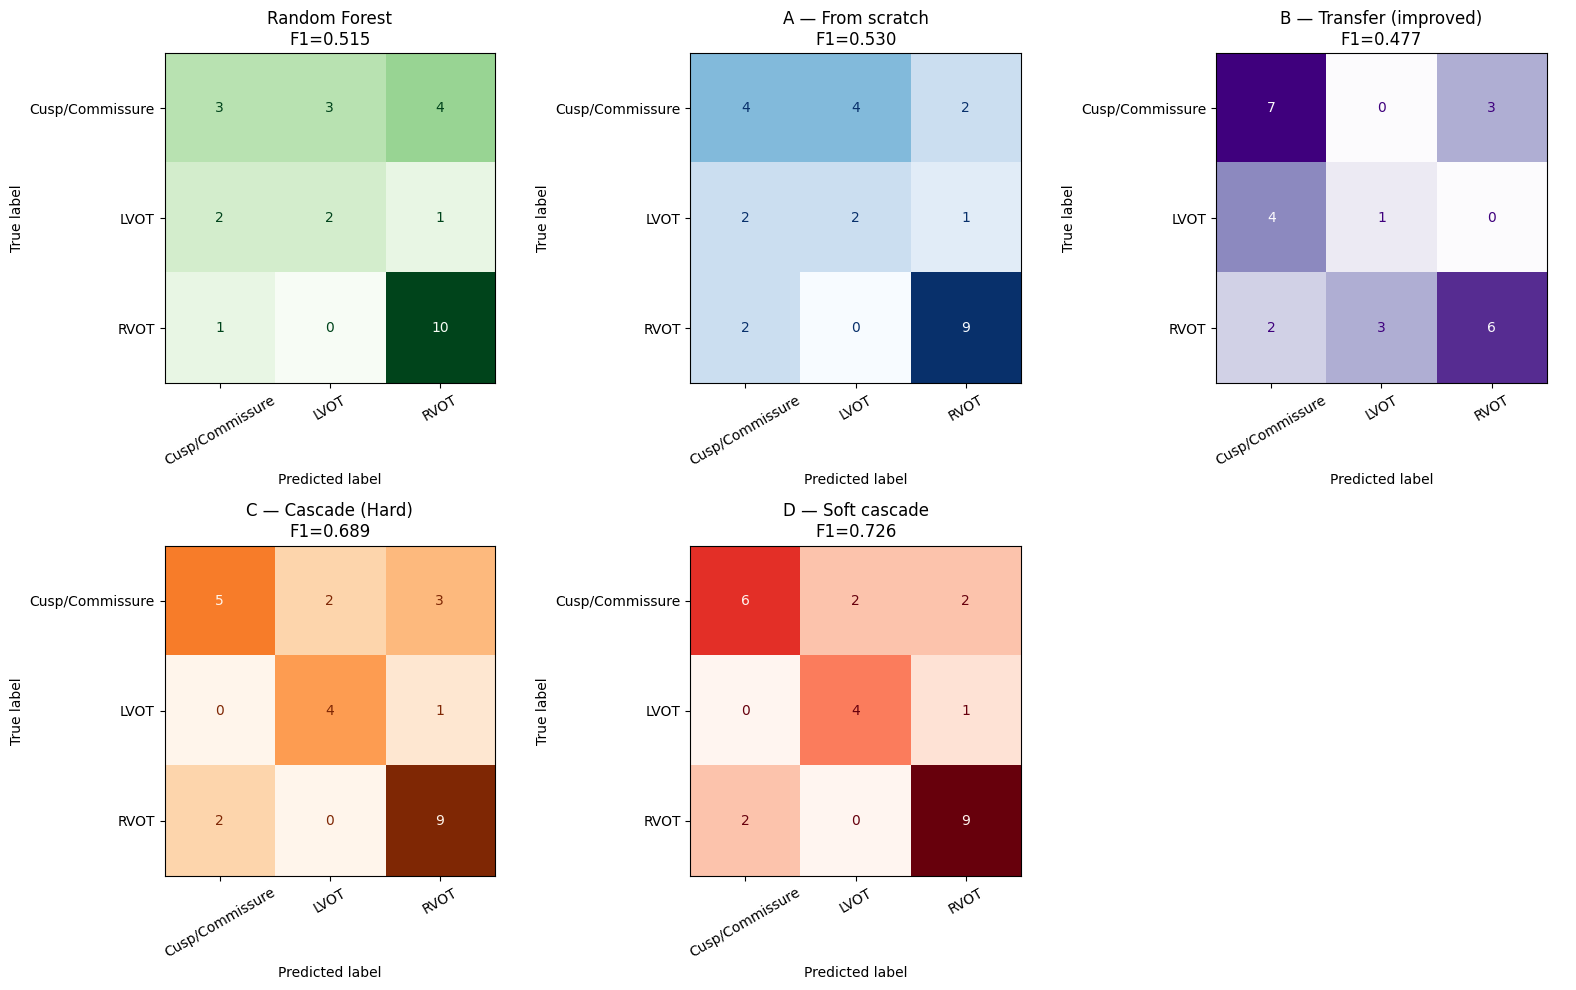

In [33]:
# Confusion matrices side by side (Updated for 6 models)
labels = list(le3.classes_)
fig, axes = plt.subplots(2, 3, figsize=(16, 10)) # Expanded to a 2x3 grid

# 1. Random Forest
ConfusionMatrixDisplay(confusion_matrix(y_test_3, rf_pred), display_labels=labels).plot(
    cmap="Greens", ax=axes[0,0], colorbar=False, xticks_rotation=30)
axes[0,0].set_title(f"Random Forest\nF1={rf_f1:.3f}")

# 2. Strategy A — From scratch
ConfusionMatrixDisplay(confusion_matrix(y_test_3, y_pred_scratch), display_labels=labels).plot(
    cmap="Blues", ax=axes[0,1], colorbar=False, xticks_rotation=30)
axes[0,1].set_title(f"A — From scratch\nF1={scratch_f1:.3f}")

# 3. Strategy B — Transfer (improved)
ConfusionMatrixDisplay(confusion_matrix(y_test_3, y_pred_transfer), display_labels=labels).plot(
    cmap="Purples", ax=axes[0,2], colorbar=False, xticks_rotation=30)
axes[0,2].set_title(f"B — Transfer (improved)\nF1={transfer_f1:.3f}")

# 4. Strategy C — Cascade (Hard)
ConfusionMatrixDisplay(confusion_matrix(y_test_3, y_pred_cascade), display_labels=labels).plot(
    cmap="Oranges", ax=axes[1,0], colorbar=False, xticks_rotation=30)
axes[1,0].set_title(f"C — Cascade (Hard)\nF1={cascade_f1:.3f}")

# 5. Strategy C — Cascade (Soft)
ConfusionMatrixDisplay(confusion_matrix(y_test_3, y_pred_cascade_soft), display_labels=labels).plot(
    cmap="Reds", ax=axes[1,1], colorbar=False, xticks_rotation=30)
axes[1,1].set_title(f"D — Soft cascade\nF1={soft_cascade_f1:.3f}")

# Hide the unused 6th subplot (row 1, column 2) to eliminate the empty white box
axes[1,2].axis('off')

plt.tight_layout()
plt.show()

---
##  Interpretability — Feature importance of Random Forest

**Why this analysis**: in Task 1, the saliency analysis revealed that the CNN had learned V3 as the most important lead — consistent with the clinical literature. Here we do the analogous thing for Task 2: which **handcrafted features** does the Random Forest find most informative for distinguishing the 3 classes?

This is a useful complement because:
- The CNN operates on raw ECG and we can't easily extract per-feature importance.
- The RF operates on interpretable named features (PVC_transition, V3_RS_balance, etc.).
- It gives us a continuity check with Task 1: do the same anatomical signals (V3, R/S transition) still rank highest?


Top 15 features by Random Forest importance:
   1. V3_max                        : 0.0498
   2. PVC_transition                : 0.0436
   3. V3_RS_balance                 : 0.0427
   4. V2_RS_balance                 : 0.0407
   5. V4_meanabs                    : 0.0387
   6. V2_meanabs                    : 0.0333
   7. V3_meanabs                    : 0.0323
   8. V1_RS_balance                 : 0.0318
   9. V4_ptp                        : 0.0312
  10. V5_min                        : 0.0280
  11. V6_min                        : 0.0266
  12. V6_meanabs                    : 0.0254
  13. AVL_meanabs                   : 0.0222
  14. V4_max                        : 0.0219
  15. V1_min                        : 0.0209


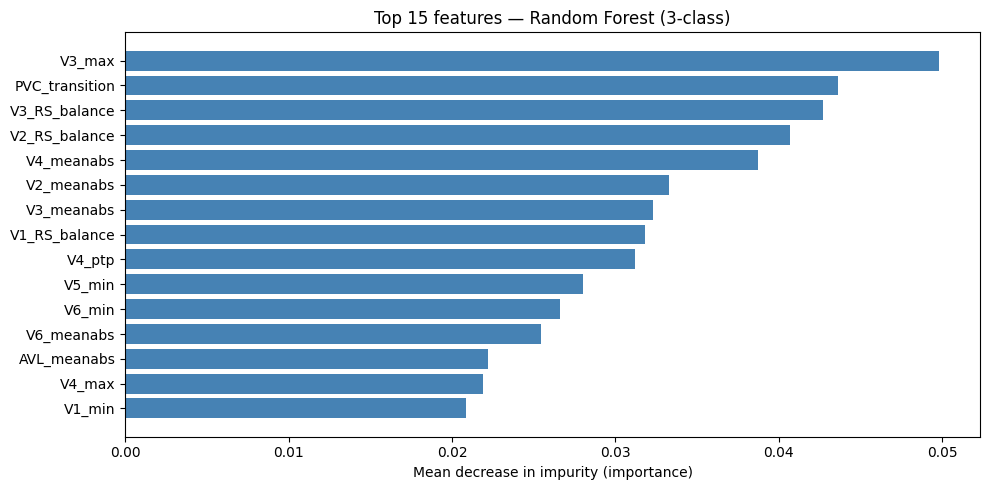

In [34]:
# Train an RF on the full handcrafted feature set and extract feature importance
rf_for_importance = RandomForestClassifier(
    n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
)
# Simple imputation first
imp = SimpleImputer(strategy="median")
X_RF_train_imp = imp.fit_transform(X_RF_train)
rf_for_importance.fit(X_RF_train_imp, y_train_3)

# Get top features
importances = rf_for_importance.feature_importances_
feature_names = list(X_RF_train.columns)
indices = np.argsort(importances)[::-1][:15]  # top 15

print("Top 15 features by Random Forest importance:")
for rank, idx in enumerate(indices, 1):
    print(f"  {rank:2d}. {feature_names[idx]:30s}: {importances[idx]:.4f}")

# Plot top 15
fig, ax = plt.subplots(figsize=(10, 5))
top_features = [feature_names[i] for i in indices]
top_importances = importances[indices]
ax.barh(range(len(indices)), top_importances[::-1], color="steelblue")
ax.set_yticks(range(len(indices)))
ax.set_yticklabels(top_features[::-1])
ax.set_xlabel("Mean decrease in impurity (importance)")
ax.set_title("Top 15 features — Random Forest (3-class)")
plt.tight_layout()
plt.show()

Interpretation: features related to V2, V3, V4 (precordial transition zone)
should dominate, consistent with Task 1's saliency finding that V3 is the
most informative lead. Look for: PVC_transition, V3_max/min/RS_balance,
V2/V4 amplitudes. Clinical features (Age, HTA) appear at lower ranks.

---
## Interpretability — t-SNE of CNN-learned embeddings

**What it does**: extract the **64-dimensional features** that the CNN learned (the output right before the final classification layer), and project them to 2D using **t-SNE** (t-distributed Stochastic Neighbor Embedding).

**Why this is useful**:
- Reveals **whether the network internally separates the 3 classes** before the final decision.
- If we see clear class clusters in 2D → the CNN learned a discriminative representation.
- If classes overlap heavily → the model struggles with class separation in feature space.
- Tightly grouped clusters of misclassified patients can be visually inspected.


Embeddings shape: (103, 64)  (n_patients × 64 features)
Running t-SNE (perplexity=15, may take ~30s)...


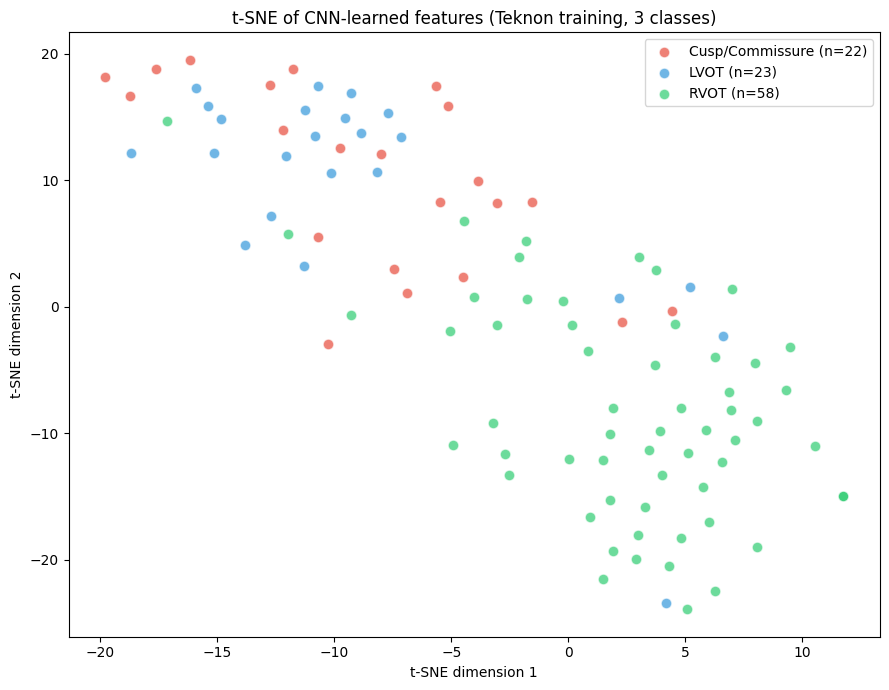

In [35]:
from sklearn.manifold import TSNE

# Use the strong binary CNN as feature extractor — it has the richest representation
# learned from the combined dataset (479 patients)
class FeatureExtractor(nn.Module):
    """Removes the final classification layer to expose the 64-d features."""
    def __init__(self, full_model):
        super().__init__()
        # Copy everything except the final Linear layer in classifier
        self.full = full_model

    def forward(self, x):
        x = self.full.block1(x)
        x = self.full.block2(x)
        x = self.full.block3(x)
        x = self.full.block4(x)
        x = self.full.dropout(x)
        x = self.full.fuse(x)
        x = self.full.gap(x)
        x = nn.Flatten()(x)
        return x   # shape: (B, 64)


# Extract features for all 3-class training patients (Teknon train)
feat_extractor = FeatureExtractor(strong_binary_model).to(DEVICE)
feat_extractor.eval()

X_3class_train_tensor = torch.from_numpy(X_Teknon_train_3d).float().to(DEVICE)
with torch.no_grad():
    train_embeddings = feat_extractor(X_3class_train_tensor).cpu().numpy()
print(f"Embeddings shape: {train_embeddings.shape}  (n_patients × 64 features)")

# Apply t-SNE
print("Running t-SNE (perplexity=15, may take ~30s)...")
tsne = TSNE(n_components=2, perplexity=15, random_state=42, init="pca")
emb_2d = tsne.fit_transform(train_embeddings)

# Plot, colored by 3-class label
class_names = list(le3.classes_)
colors = ["#e74c3c", "#3498db", "#2ecc71"]   # red, blue, green

fig, ax = plt.subplots(figsize=(9, 7))
for cls_idx, cls_name in enumerate(class_names):
    mask = y_train_3 == cls_idx
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=colors[cls_idx],
               label=f"{cls_name} (n={mask.sum()})", s=60, alpha=0.7, edgecolor="white")
ax.set_xlabel("t-SNE dimension 1")
ax.set_ylabel("t-SNE dimension 2")
ax.set_title("t-SNE of CNN-learned features (Teknon training, 3 classes)")
ax.legend()
plt.tight_layout()
plt.show()

Interpretation: features related to V2, V3, V4 (precordial transition zone)
should dominate, consistent with Task 1's saliency finding that V3 is the
most informative lead. Look for: PVC_transition, V3_max/min/RS_balance,
V2/V4 amplitudes. Clinical features (Age, HTA) appear at lower ranks.

---
## 14. Failure analysis (best model)

For the cascade strategy specifically, we can also analyze **at which stage** the model fails: did Stage 1 already misclassify the lateralization, or did Stage 1 succeed but Stage 2 failed?


In [36]:
# Find the best model
strategies = [
    ("A — From scratch", y_pred_scratch,  scratch_f1),
    ("B — Transfer improved", y_pred_transfer, transfer_f1),
    ("C — Cascade", y_pred_cascade, cascade_f1),
]
best_name, best_pred, best_f1_val = max(strategies, key=lambda t: t[2])
print(f"Failure analysis on: {best_name} (F1={best_f1_val:.3f})\n")

fail_rows = []
for i in range(len(y_test_3)):
    if best_pred[i] != y_test_3[i]:
        row = teknon_test.iloc[i]
        entry = {
            "test_idx": i,
            "true": le3.inverse_transform([y_test_3[i]])[0],
            "predicted": le3.inverse_transform([best_pred[i]])[0],
            "transition": row.get("PVC_transition","N/A"),
            "SOO_std": row.get("SOO_std","N/A"),
        }
        if best_name.startswith("C"):
            entry["stage1"] = "LVOT" if stage1_pred[i] == bin_lvot else "RVOT"
            entry["true_lat"] = "LVOT" if y_test_3[i] != rvot_idx else "RVOT"
        fail_rows.append(entry)

if not fail_rows:
    print("No misclassifications.")
else:
    fail_df = pd.DataFrame(fail_rows)
    print(f"Misclassifications: {len(fail_df)} / {len(y_test_3)}\n")
    print(fail_df.to_string(index=False))
    print("\n── By R/S transition ──")
    print(fail_df["transition"].value_counts(dropna=False))
    print("\n── Direction of confusion ──")
    pairs = fail_df.apply(lambda r: f"{r['true']} → {r['predicted']}", axis=1)
    print(pairs.value_counts())
    if best_name.startswith("C"):
        print("\n Cascade stage analysis")
        for _, r in fail_df.iterrows():
            stage1_ok = "✓" if r["stage1"] == r["true_lat"] else "✗"
            print(f"  test_idx {r['test_idx']}: stage1 {stage1_ok}  (true={r['true']}, predicted={r['predicted']})")


Failure analysis on: C — Cascade (F1=0.689)

Misclassifications: 8 / 26

 test_idx            true       predicted transition          SOO_std stage1 true_lat
        0 Cusp/Commissure            RVOT         V3              LCC   RVOT     LVOT
        5 Cusp/Commissure            RVOT         V3              LCC   RVOT     LVOT
        6            RVOT Cusp/Commissure         V4      RVOT Septum   LVOT     RVOT
        8            LVOT            RVOT         V3 LVOT Subvalvular   RVOT     LVOT
       10 Cusp/Commissure            LVOT         V1              RCC   LVOT     LVOT
       17            RVOT Cusp/Commissure         V3      RVOT Septum   LVOT     RVOT
       22 Cusp/Commissure            LVOT         V4       COMMISSURE   LVOT     LVOT
       24 Cusp/Commissure            RVOT         V3              RCC   RVOT     LVOT

── By R/S transition ──
transition
V3    5
V4    2
V1    1
Name: count, dtype: int64

── Direction of confusion ──
Cusp/Commissure → RVOT    3
RVOT → Cu

---
##  Conclusions

**Final ranking (test F1-macro)**:

1. **Soft Cascade (Strategy 4)**: 0.726 (best)
2. **Hard Cascade (Strategy 3)**: 0.689
3. **CNN from scratch (Strategy 1)**: 0.530
4. **Random Forest (Strategy 7)**: 0.515
5. **PCA + HistGradientBoosting (Strategy 5)**: 0.510
6. **CNN Transfer Learning (Strategy 2)**: 0.477
7. **Expanded Pool (Strategy 6)**: 0.435


